# Laboratorijska vježba 4 — detekcija značajki i konvolucija

Obuhvaćeni su Cannyjevi rubovi, Houghove pravci, Harrisovi kutovi, ORB značajke i ručno implementirana konvolucija.

In [1]:
from pathlib import Path
import math
import time
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

IMG = Path('images')

def show(images, titles, cmaps=None, figsize=(15, 5)):
    """Prikaži jednu ili više slika bez skrivene promjene raspona vrijednosti."""
    if not isinstance(images, (list, tuple)):
        images, titles = [images], [titles]
    if cmaps is None:
        cmaps = [None] * len(images)
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Zadatak 1 — Cannyjev detektor rubova

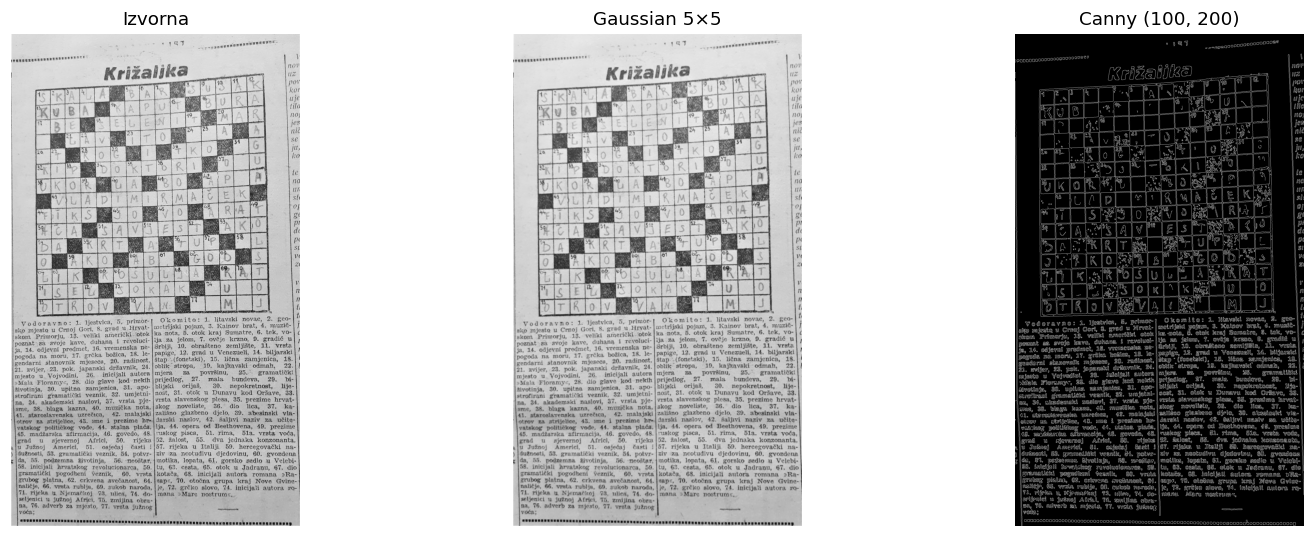

In [2]:
gray = cv.imread(str(IMG / 'crossword.jpg'), cv.IMREAD_GRAYSCALE)
assert gray is not None
blurred = cv.GaussianBlur(gray, (5, 5), 1.2)
edges = cv.Canny(blurred, 100, 200)
show([gray, blurred, edges], ['Izvorna', 'Gaussian 5×5', 'Canny (100, 200)'], ['gray'] * 3)

Odabrani pragovi 100 i 200 zadržavaju glavne rubove križaljke uz prihvatljivu količinu sitnih odgovora. Veći pragovi uklanjaju slabije rubove, a manji povećavaju broj lažnih rubova.

## Zadaci 2 i 3 — Houghova transformacija

Uspoređuju se koraci kuta π/90 i π/180. Fini korak daje precizniji kut i u pravilu više sličnih detekcija.

π/90: 13517 detekcija; π/180: 28618 detekcija.


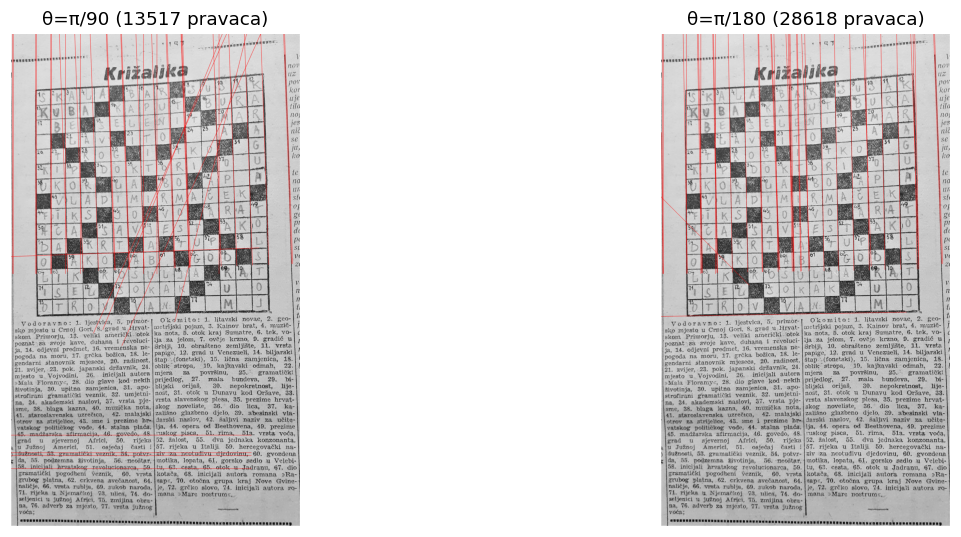

In [3]:
def draw_hough(gray_image, theta_step, threshold=135):
    edge_map = cv.Canny(cv.GaussianBlur(gray_image, (5, 5), 1.2), 100, 200)
    lines = cv.HoughLines(edge_map, 1, theta_step, threshold)
    canvas = cv.cvtColor(gray_image, cv.COLOR_GRAY2RGB)
    if lines is not None:
        for rho, theta in lines[:, 0][:40]:
            a, b = np.cos(theta), np.sin(theta)
            x0, y0 = a * rho, b * rho
            p1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * a))
            p2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * a))
            cv.line(canvas, p1, p2, (255, 0, 0), 1, cv.LINE_AA)
    return canvas, 0 if lines is None else len(lines)

hough90, n90 = draw_hough(gray, np.pi / 90)
hough180, n180 = draw_hough(gray, np.pi / 180)
show([hough90, hough180], [f'θ=π/90 ({n90} pravaca)', f'θ=π/180 ({n180} pravaca)'])
print(f'π/90: {n90} detekcija; π/180: {n180} detekcija.')

## Zadatak 4 — Harrisovi kutovi

Broj označenih piksela odgovora: 1046223


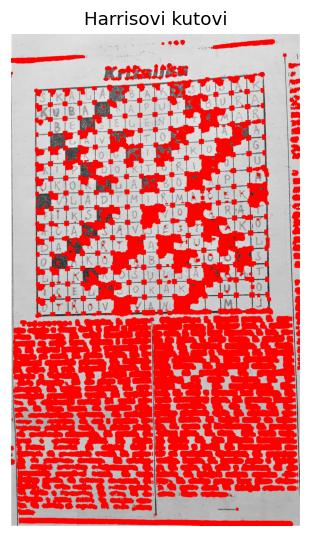

In [4]:
harris_input = np.float32(gray) / 255.0
response = cv.cornerHarris(harris_input, blockSize=15, ksize=3, k=0.05)
response = cv.dilate(response, None)
corner_mask = response > 0.01 * response.max()
harris_vis = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)
harris_vis[corner_mask] = (255, 0, 0)
show(harris_vis, 'Harrisovi kutovi')
print('Broj označenih piksela odgovora:', int(corner_mask.sum()))

## ORB — ključne točke i podudaranje dviju slika

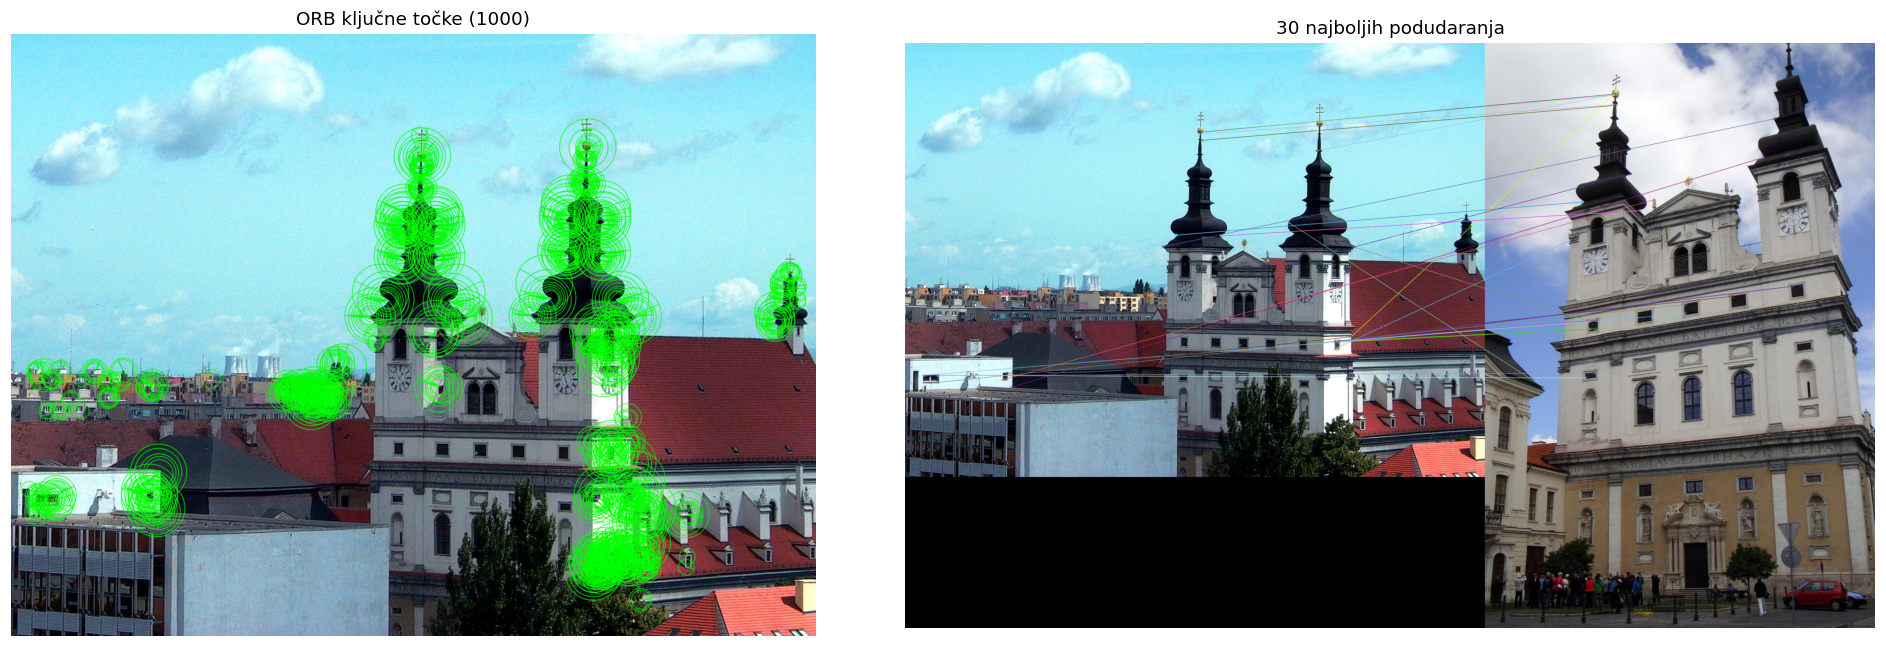

In [5]:
building1 = cv.imread(str(IMG / 'building_1.jpg'))
building2 = cv.imread(str(IMG / 'building_2.jpg'))
assert building1 is not None and building2 is not None

orb = cv.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(building1, None)
kp2, des2 = orb.detectAndCompute(building2, None)
keypoint_vis = cv.drawKeypoints(building1, kp1, None, color=(0, 255, 0),
                               flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

matcher = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = sorted(matcher.match(des1, des2), key=lambda m: m.distance)
match_vis = cv.drawMatches(building1, kp1, building2, kp2, matches[:30], None,
                           flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show([cv.cvtColor(keypoint_vis, cv.COLOR_BGR2RGB), cv.cvtColor(match_vis, cv.COLOR_BGR2RGB)],
     [f'ORB ključne točke ({len(kp1)})', '30 najboljih podudaranja'], figsize=(18, 6))

## Ručna konvolucija: Python i NumPy

Obje funkcije koriste nulama dopunjenu sliku i istu korelacijsku konvenciju kao `cv.filter2D`. Rezultati se uspoređuju numerički.

Python petlje: 0.0232 s | NumPy jezgra: 0.0333 s
Najveća apsolutna razlika: 0.0


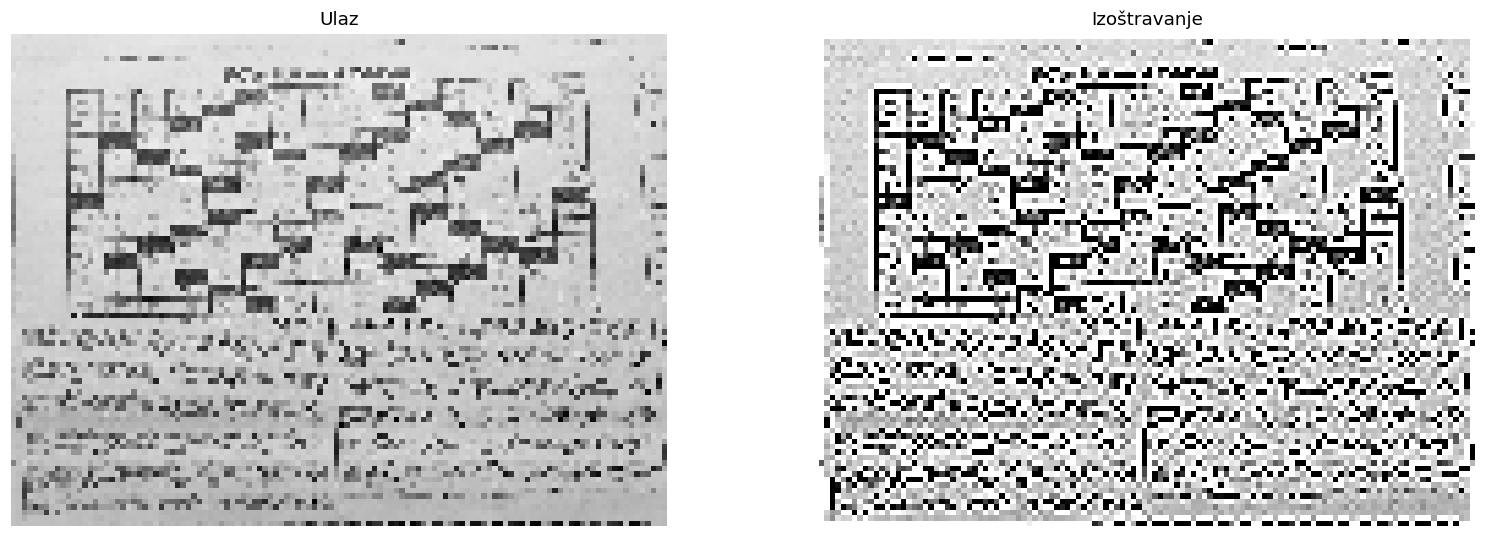

In [6]:
def convolve_py(img, kernel):
    img = np.asarray(img, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)
    kh, kw = kernel.shape
    py, px = kh // 2, kw // 2
    padded = np.pad(img, ((py, py), (px, px)), mode='constant')
    result = np.zeros_like(img, dtype=np.float32)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            total = 0.0
            for j in range(kh):
                for i in range(kw):
                    total += padded[y + j, x + i] * kernel[j, i]
            result[y, x] = total
    return result

def convolve_np(img, kernel):
    img = np.asarray(img, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)
    kh, kw = kernel.shape
    py, px = kh // 2, kw // 2
    padded = np.pad(img, ((py, py), (px, px)), mode='constant')
    result = np.zeros_like(img, dtype=np.float32)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            result[y, x] = np.sum(padded[y:y+kh, x:x+kw] * kernel)
    return result

small = cv.resize(gray, (120, 90))
test_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], np.float32)
t0 = time.perf_counter(); result_py = convolve_py(small, test_kernel); t_py = time.perf_counter() - t0
t0 = time.perf_counter(); result_np = convolve_np(small, test_kernel); t_np = time.perf_counter() - t0
print(f'Python petlje: {t_py:.4f} s | NumPy jezgra: {t_np:.4f} s')
print('Najveća apsolutna razlika:', float(np.max(np.abs(result_py - result_np))))
show([small, np.clip(result_np, 0, 255)], ['Ulaz', 'Izoštravanje'], ['gray', 'gray'])

## Jezgre za rubove i zamućenje

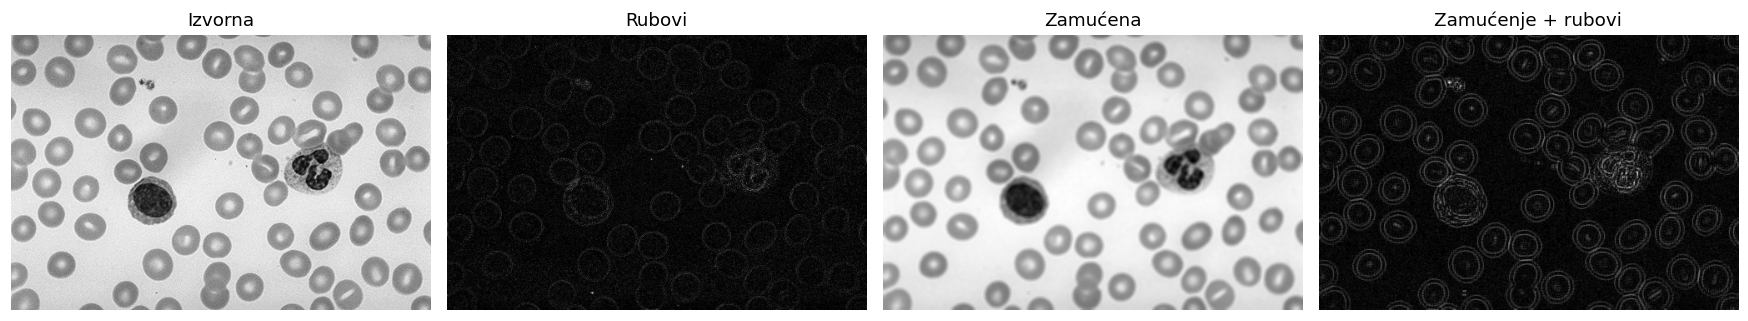

In [7]:
cells = cv.imread(str(IMG / 'cells.jpg'), cv.IMREAD_GRAYSCALE)
assert cells is not None
kernel_edge = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], np.float32)
kernel_blur = np.ones((5, 5), np.float32) / 25.0

edge_result = cv.filter2D(cells, cv.CV_32F, kernel_edge)
blur_result = cv.filter2D(cells, -1, kernel_blur)
blur_edge_result = cv.filter2D(blur_result, cv.CV_32F, kernel_edge)
show([cells, np.abs(edge_result), blur_result, np.abs(blur_edge_result)],
     ['Izvorna', 'Rubovi', 'Zamućena', 'Zamućenje + rubovi'], ['gray'] * 4, figsize=(16, 4))

## Velika kružna jezgra

Impulsi u ulaznoj slici nakon filtriranja poprimaju oblik jezgre. Time se dobiva više kružnica na zadanim položajima.

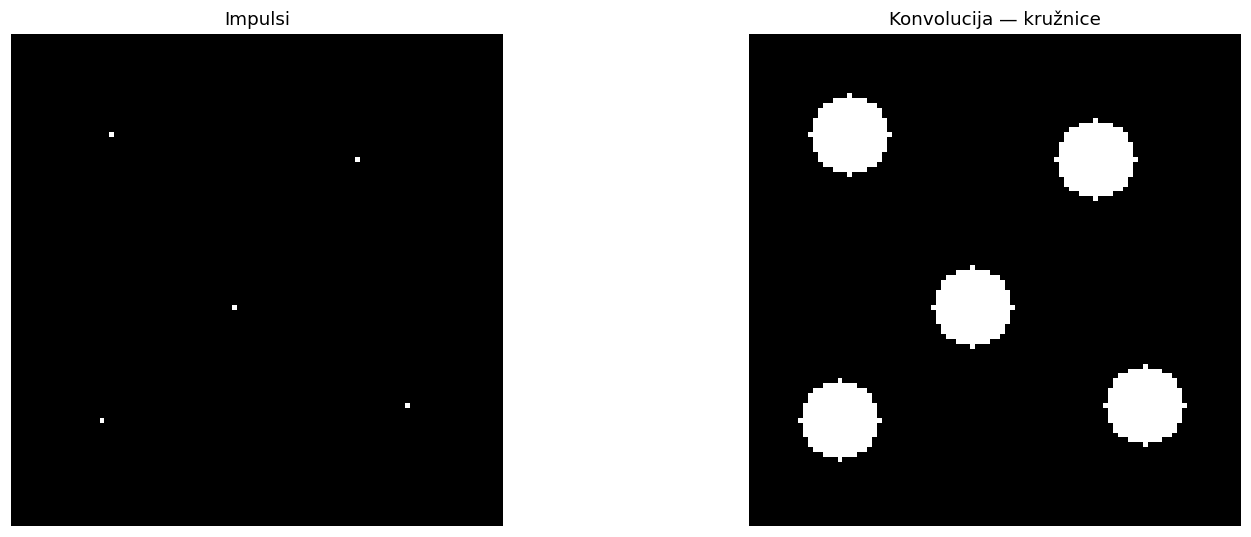

In [8]:
radius = 8
size = 2 * radius + 1
yy, xx = np.ogrid[:size, :size]
circle_kernel = (((xx - radius) ** 2 + (yy - radius) ** 2) <= radius ** 2).astype(np.float32)
circle_kernel /= circle_kernel.max()

impulses = np.zeros((100, 100), np.float32)
for y, x in [(20, 20), (25, 70), (55, 45), (75, 80), (78, 18)]:
    impulses[y, x] = 255
circles = cv.filter2D(impulses, -1, circle_kernel)
show([impulses, circles], ['Impulsi', 'Konvolucija — kružnice'], ['gray', 'gray'])

## Detekcija očiju i usta prilagođenim jezgrama

Jezgra za oči traži prijelaz svijetlo–tamno u vodoravnom smjeru. Jezgra za usta traži tamnu vodoravnu strukturu između svjetlijih područja.

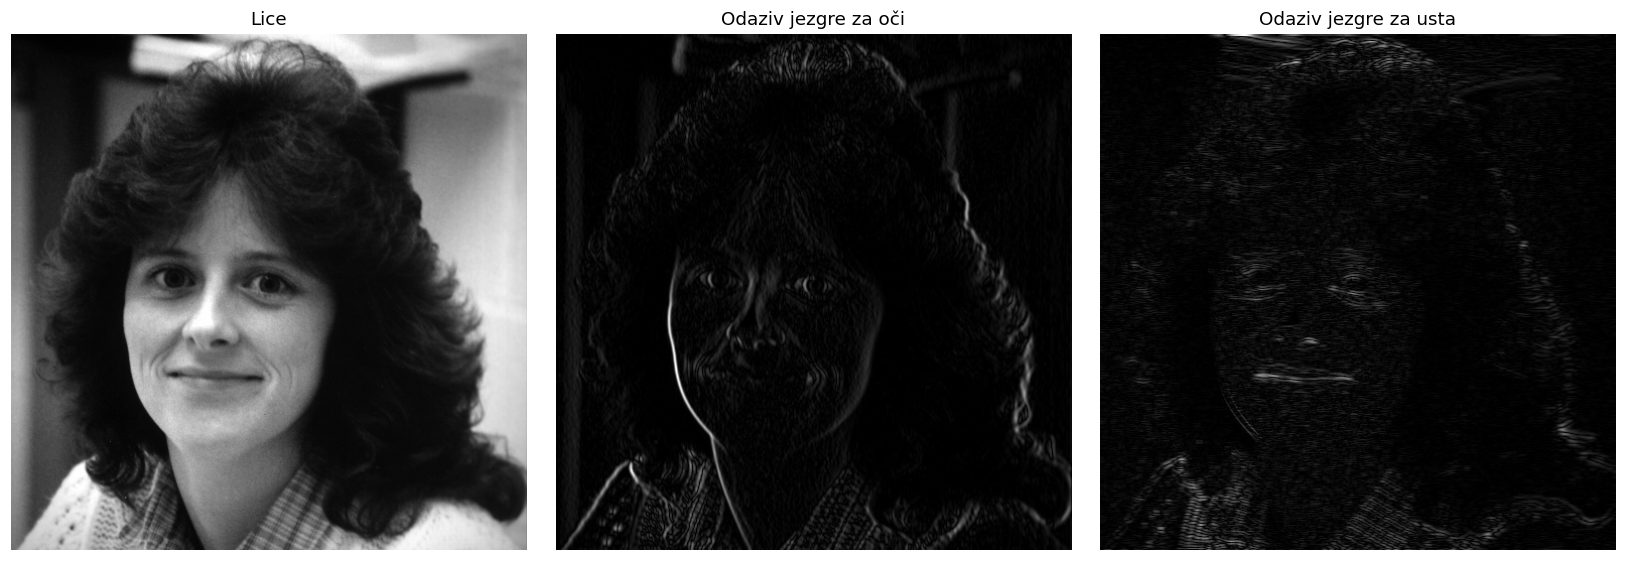

In [9]:
woman = cv.imread(str(IMG / 'woman_darkhair.png'), cv.IMREAD_GRAYSCALE)
assert woman is not None

kernel_eye = np.array([
    [1, 1, -1, -1],
    [1, 1, -1, -1],
    [1, 1, -1, -1],
    [1, 1, -1, -1],
], dtype=np.float32)

kernel_mouth = np.array([
    [-1, -1, -1, -1, -1, -1, -1],
    [ 1,  1,  1,  1,  1,  1,  1],
    [ 1,  1,  1,  1,  1,  1,  1],
    [-1, -1, -1, -1, -1, -1, -1],
], dtype=np.float32)

eye_response = cv.filter2D(woman, cv.CV_32F, kernel_eye)
mouth_response = cv.filter2D(woman, cv.CV_32F, kernel_mouth)
show([woman, np.abs(eye_response), np.abs(mouth_response)],
     ['Lice', 'Odaziv jezgre za oči', 'Odaziv jezgre za usta'], ['gray'] * 3)

## Zaključak

Detektori reagiraju na različite lokalne strukture: Canny na gradijente, Hough na globalno poravnate rubove, Harris na promjene u dva smjera, a ORB na ponovljive ključne točke. Ručna konvolucija potvrđuje isti princip, uz znatno veću brzinu vektoriziranog izračuna.